In [15]:
# Import required libraries for analysis and visualisation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Load cleaned datasets from outputs folder

customers_clean = pd.read_csv("../outputs/customers_clean.csv")
orders_clean = pd.read_csv("../outputs/orders_clean.csv")
deliveries_clean = pd.read_csv("../outputs/deliveries_clean.csv")
drivers_clean = pd.read_csv("../outputs/drivers_clean.csv")
vehicles_clean = pd.read_csv("../outputs/vehicles_clean.csv")
hubs_clean = pd.read_csv("../outputs/hubs_clean.csv")
complaints_clean = pd.read_csv("../outputs/complaints_clean.csv")
incidents_clean = pd.read_csv("../outputs/incidents_clean.csv")
app_events_clean = pd.read_csv("../outputs/app_events_clean.csv")

delivery_analysis_clean = pd.read_csv("../outputs/delivery_analysis_clean.csv")
complaints_analysis_clean = pd.read_csv("../outputs/complaints_analysis_clean.csv")
incidents_analysis_clean = pd.read_csv("../outputs/incidents_analysis_clean.csv")

DELIVERY PERFORMANCE ANALYSIS

In [17]:
# Count delivery statuses

delivery_status_counts = deliveries_clean["delivery_status"].value_counts()

print(delivery_status_counts)

delivery_status
ontime     540
delayed    198
failed     129
Name: count, dtype: int64


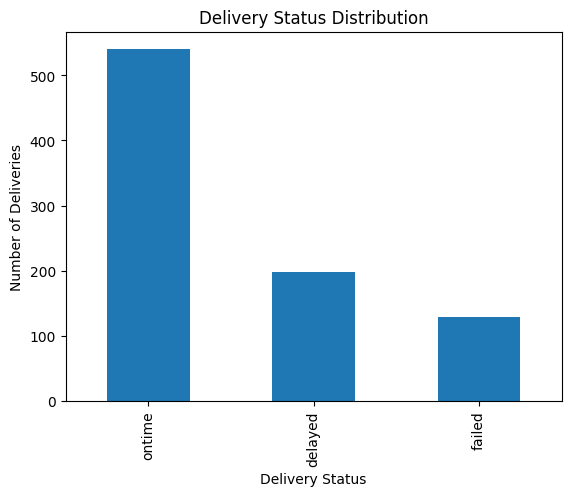

In [18]:
# Visualise delivery status distribution

delivery_status_counts.plot(kind="bar")

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")

plt.show()

In [19]:
# Calculate percentage of delayed deliveries

delay_rate = deliveries_clean["is_delayed"].mean() * 100

print("Delay Rate:", round(delay_rate, 2), "%")

Delay Rate: 50.17 %


In [20]:
# Calculate percentage of failed deliveries

failure_rate = deliveries_clean["is_failed"].mean() * 100

print("Failed Delivery Rate:", round(failure_rate, 2), "%")

Failed Delivery Rate: 14.88 %


In [21]:
# Display statistical summary for delivery duration

deliveries_clean["delivery_duration_minutes"].describe()

count     867.000000
mean      619.029051
std       507.787411
min         1.353885
25%       210.101327
50%       474.786537
75%       931.684706
max      2607.415092
Name: delivery_duration_minutes, dtype: float64

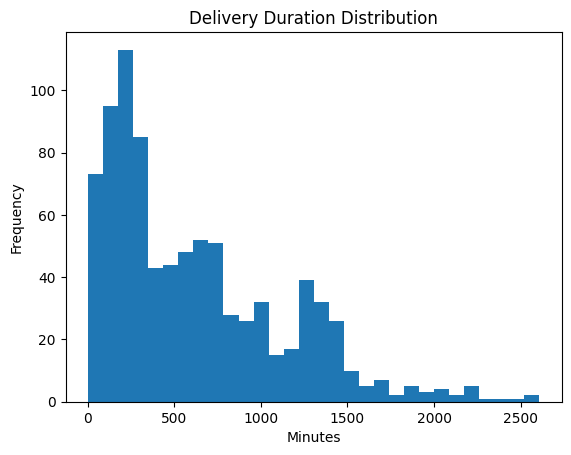

In [22]:
# Plot delivery duration distribution

deliveries_clean["delivery_duration_minutes"].plot(kind="hist", bins=30)

plt.title("Delivery Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")

plt.show()

HUB PERFORMANCE ANALYSIS

In [23]:
# Count deliveries handled by each hub

hub_delivery_counts = delivery_analysis_clean["hub_name"].value_counts()

print(hub_delivery_counts)

hub_name
North Exchange    118
Midtown Relay     118
West Gate         116
Central Core      108
Riverside Hub     108
East Dock         107
South Link         97
Airport Hub        95
Name: count, dtype: int64


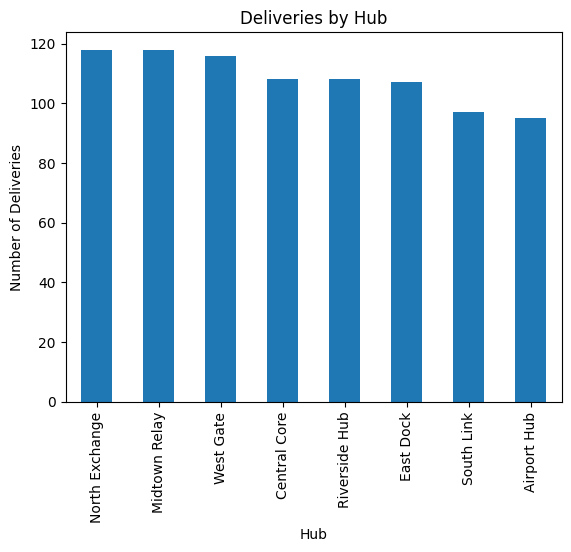

In [24]:
# Visualise delivery volume by hub

hub_delivery_counts.plot(kind="bar")

plt.title("Deliveries by Hub")
plt.xlabel("Hub")
plt.ylabel("Number of Deliveries")

plt.show()

In [25]:
# Calculate average delay rate for each hub

hub_delay_rate = (
    delivery_analysis_clean
    .groupby("hub_name")["is_delayed"]
    .mean()
    .sort_values(ascending=False)
)

print(hub_delay_rate)

hub_name
Airport Hub       0.621053
Central Core      0.546296
West Gate         0.517241
Midtown Relay     0.508475
North Exchange    0.491525
East Dock         0.457944
South Link        0.453608
Riverside Hub     0.425926
Name: is_delayed, dtype: float64


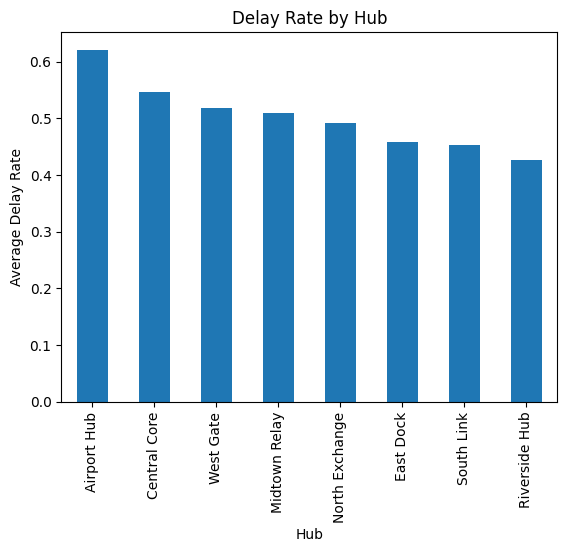

In [26]:
# Visualise hub delay rates

hub_delay_rate.plot(kind="bar")

plt.title("Delay Rate by Hub")
plt.xlabel("Hub")
plt.ylabel("Average Delay Rate")

plt.show()

hub_name
Central Core      0.212963
Midtown Relay     0.211864
Airport Hub       0.157895
North Exchange    0.135593
Riverside Hub     0.129630
West Gate         0.129310
South Link        0.103093
East Dock         0.102804
Name: is_failed, dtype: float64


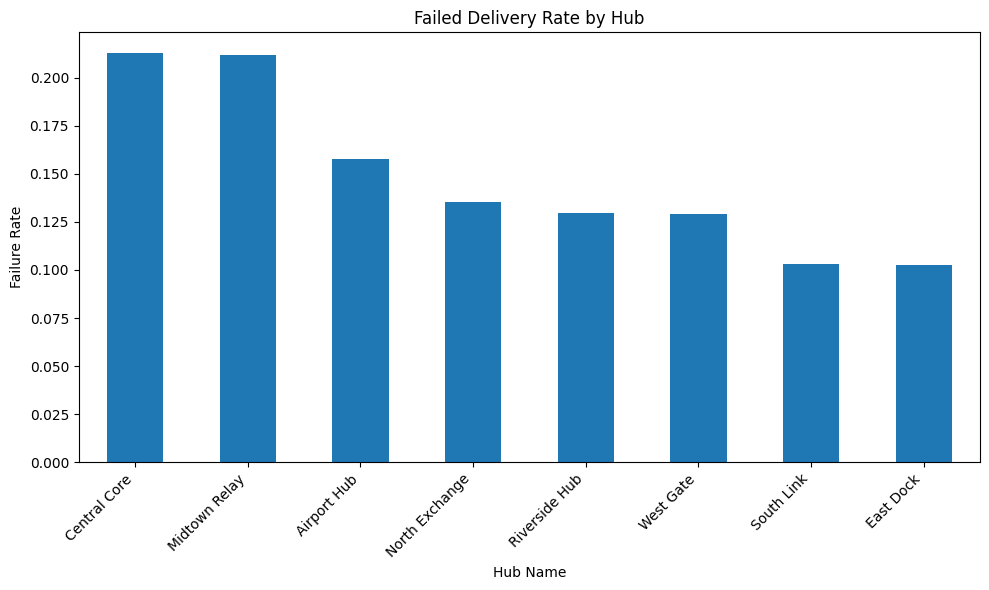

In [29]:
# Calculate failed delivery rate for each hub

hub_failure_rate = (
    delivery_analysis_clean
    .groupby("hub_name")["is_failed"]
    .mean()
    .sort_values(ascending=False)
)

print(hub_failure_rate)

plt.figure(figsize=(10, 6))

hub_failure_rate.plot(kind="bar")

plt.title("Failed Delivery Rate by Hub")
plt.xlabel("Hub Name")
plt.ylabel("Failure Rate")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

CUSTOMER COMPLAINT ANALYSIS

In [ ]:
# Count complaint types

complaint_counts = complaints_clean["complaint_type"].value_counts()

print(complaint_counts)

complaint_type
delay                101
missedpickup          64
appissue              53
driverbehaviour       51
supportexperience     20
billing               16
damage                15
Name: count, dtype: int64


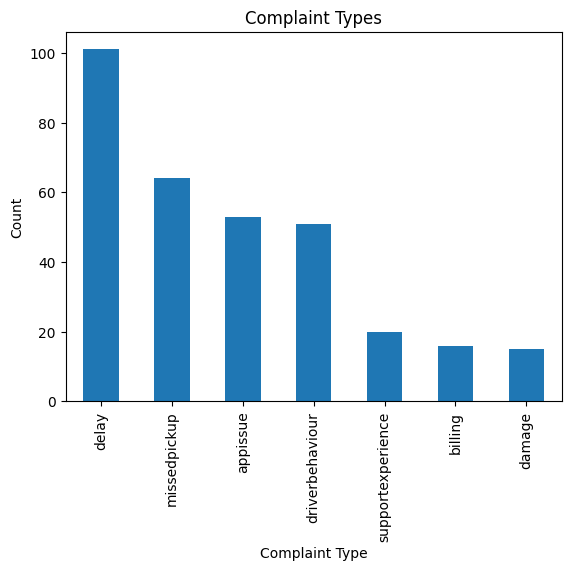

In [ ]:
# Visualise complaint categories

complaint_counts.plot(kind="bar")

plt.title("Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Count")

plt.show()

severity
medium    172
high       77
low        71
Name: count, dtype: int64


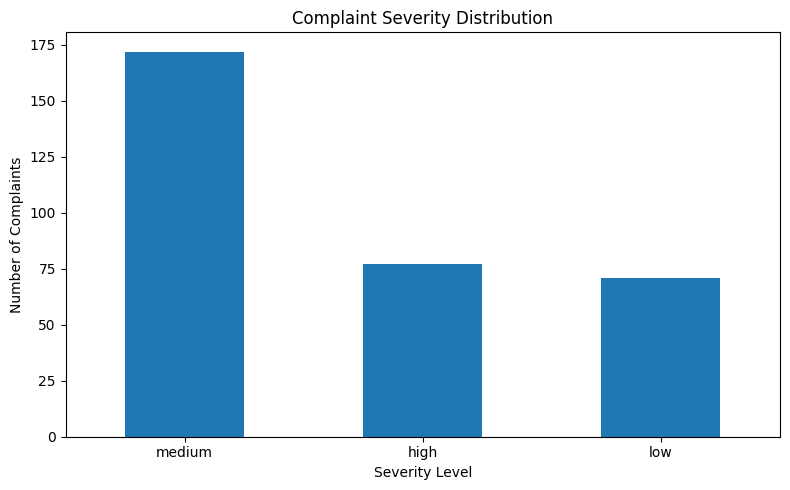

In [30]:
# Count complaint severity levels

severity_counts = complaints_clean["severity"].value_counts()

print(severity_counts)

plt.figure(figsize=(8, 5))

severity_counts.plot(kind="bar")

plt.title("Complaint Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [ ]:
# Calculate average complaint resolution time

average_resolution_days = complaints_clean["resolution_days"].mean()

print("Average Resolution Days:", round(average_resolution_days, 2))

Average Resolution Days: 7.93


In [ ]:
# Analyse compensation costs

complaints_clean["compensation_amount"].describe()

count    320.000000
mean      19.244344
std       15.275150
min        0.000000
25%        7.142500
50%       17.230000
75%       27.955000
max       61.850000
Name: compensation_amount, dtype: float64

DRIVER PERFORMANCE ANALYSIS

In [ ]:
# Analyse driver rating distribution

drivers_clean["driver_rating"].describe()

count    170.000000
mean       4.171706
std        0.406301
min        3.150000
25%        3.905000
50%        4.175000
75%        4.477500
max        5.000000
Name: driver_rating, dtype: float64

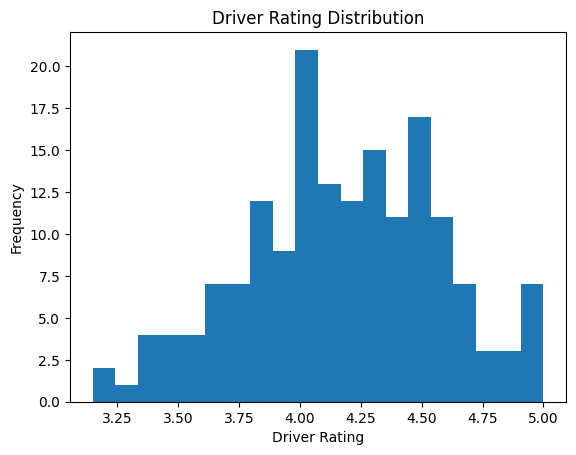

In [ ]:
# Visualise driver ratings

drivers_clean["driver_rating"].plot(kind="hist", bins=20)

plt.title("Driver Rating Distribution")
plt.xlabel("Driver Rating")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Count incidents by driver

driver_incidents = (
    incidents_analysis_clean
    .groupby("driver_id")
    .size()
    .sort_values(ascending=False)
)

print(driver_incidents.head(10))

driver_id
D087    6
D146    5
D026    5
D039    5
D004    5
D037    4
D094    4
D154    4
D084    4
D032    4
dtype: int64


In [ ]:
# Analyse delivery status across service types

service_delivery_analysis = (
    delivery_analysis_clean
    .groupby("service_type")["is_delayed"]
    .mean()
    .sort_values(ascending=False)
)

print(service_delivery_analysis)

service_type
business     0.543860
passenger    0.527426
parcel       0.524038
medical      0.468750
retail       0.443396
Name: is_delayed, dtype: float64


VEHICLE ANALYSIS

In [ ]:
# Count vehicle types

vehicle_type_counts = vehicles_clean["vehicle_type"].value_counts()

print(vehicle_type_counts)

vehicle_type
ev          43
cargovan    30
hybrid      28
diesel      19
Name: count, dtype: int64


maintenance_status
active       67
inrepair     36
scheduled    17
Name: count, dtype: int64


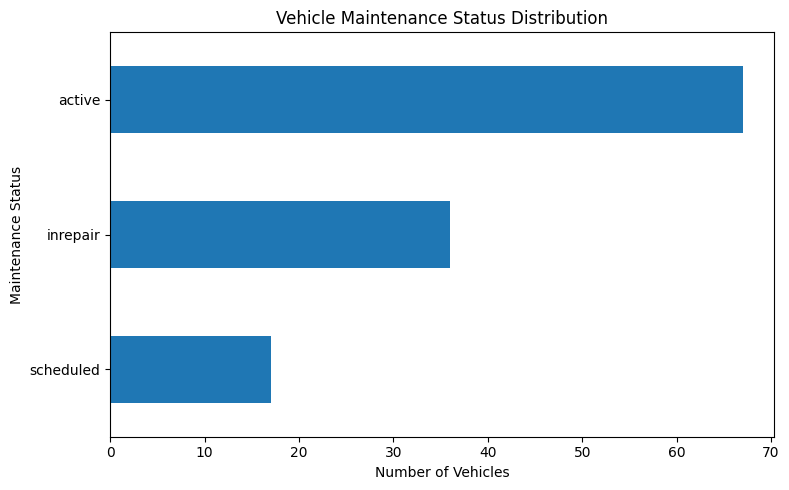

In [31]:
# Count maintenance status categories

maintenance_counts = vehicles_clean["maintenance_status"].value_counts()

print(maintenance_counts)
plt.figure(figsize=(8, 5))

maintenance_counts.sort_values().plot(kind="barh")

plt.title("Vehicle Maintenance Status Distribution")
plt.xlabel("Number of Vehicles")
plt.ylabel("Maintenance Status")

plt.tight_layout()
plt.show()

In [ ]:
# Count high-risk vehicles

high_risk_counts = vehicles_clean["high_risk_vehicle"].value_counts()

print(high_risk_counts)

high_risk_vehicle
0    61
1    59
Name: count, dtype: int64


In [ ]:
# Analyse vehicle battery health

vehicles_clean["battery_health_pct"].describe()

count    116.000000
mean      76.785345
std       12.698985
min       42.000000
25%       68.200000
50%       78.050000
75%       85.775000
max      100.000000
Name: battery_health_pct, dtype: float64

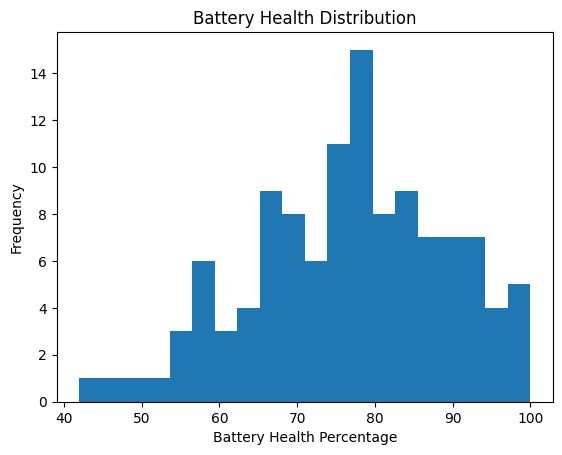

In [ ]:
# Visualise battery health distribution

vehicles_clean["battery_health_pct"].plot(kind="hist", bins=20)

plt.title("Battery Health Distribution")
plt.xlabel("Battery Health Percentage")
plt.ylabel("Frequency")

plt.show()

INCIDENT ANALYSIS

In [ ]:
# Count incident types

incident_counts = incidents_clean["incident_type"].value_counts()

print(incident_counts)

incident_type
proofmissing        46
customernoshow      44
routedeviation      43
vehiclefault        37
batteryalert        36
appsyncerror        31
temperatureissue    29
safetynearmiss      14
Name: count, dtype: int64


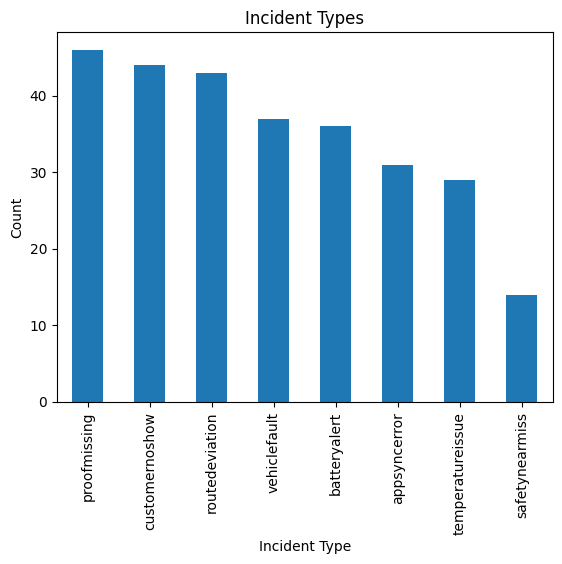

In [ ]:
# Visualise incident categories

incident_counts.plot(kind="bar")

plt.title("Incident Types")
plt.xlabel("Incident Type")
plt.ylabel("Count")

plt.show()

In [ ]:
# Count incident severity levels

incident_severity_counts = incidents_clean["severity"].value_counts()

print(incident_severity_counts)

severity
medium      106
low          79
high         68
critical     27
Name: count, dtype: int64


APP EVENT ANALYSIS

In [ ]:
# Count app event categories

event_counts = app_events_clean["event_type"].value_counts()

print(event_counts)

event_type
track_order                    138
eta_refresh                    105
search_route                    99
chat_opened                     88
delivery_instruction_update     75
payment_retry                   69
chat_escalated                  38
cancel_attempt                  28
Name: count, dtype: int64


In [33]:
# Calculate app event failure rate

app_failure_rate = app_events_clean["app_event_failed"].mean() * 100

print("App Failure Rate:", round(app_failure_rate, 2), "%")

App Failure Rate: 5.94 %


In [34]:
# Calculate percentage of high latency events

high_latency_rate = app_events_clean["high_latency_event"].mean() * 100

print("High Latency Event Rate:", round(high_latency_rate, 2), "%")

High Latency Event Rate: 71.25 %


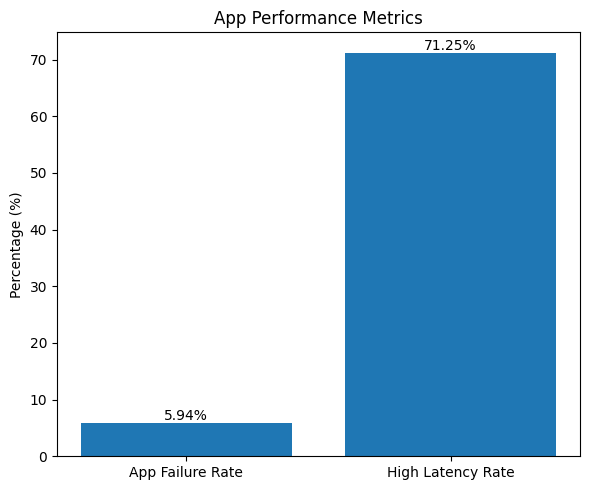

In [35]:
import matplotlib.pyplot as plt

metrics = ["App Failure Rate", "High Latency Rate"]
values = [app_failure_rate, high_latency_rate]

plt.figure(figsize=(6,5))
bars = plt.bar(metrics, values)

plt.title("App Performance Metrics")
plt.ylabel("Percentage (%)")

# Add labels on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

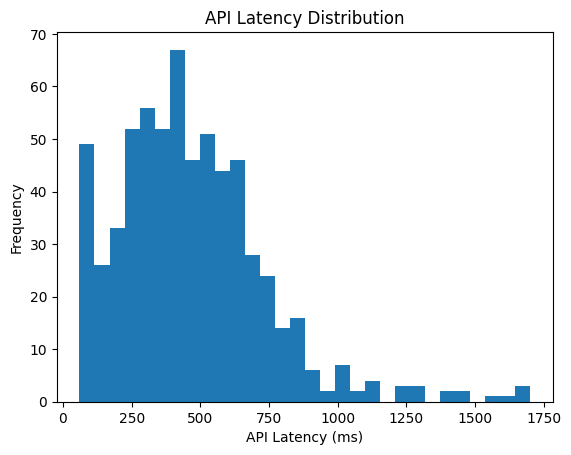

In [ ]:
# Visualise API latency distribution

app_events_clean["api_latency_ms"].plot(kind="hist", bins=30)

plt.title("API Latency Distribution")
plt.xlabel("API Latency (ms)")
plt.ylabel("Frequency")

plt.show()

CORRELATION ANALYSIS

In [ ]:
# Select numerical operational variables

correlation_data = delivery_analysis_clean[[
    "delivery_duration_minutes",
    "is_delayed",
    "is_failed",
    "customer_rating_post_delivery",
    "driver_rating",
    "battery_health_pct"
]]

# Generate correlation matrix

correlation_matrix = correlation_data.corr()

print(correlation_matrix)

                               delivery_duration_minutes  is_delayed  \
delivery_duration_minutes                       1.000000    0.367834   
is_delayed                                      0.367834    1.000000   
is_failed                                       0.369008    0.403679   
customer_rating_post_delivery                  -0.296237   -0.494045   
driver_rating                                  -0.077263   -0.060062   
battery_health_pct                             -0.015986    0.000461   

                               is_failed  customer_rating_post_delivery  \
delivery_duration_minutes       0.369008                      -0.296237   
is_delayed                      0.403679                      -0.494045   
is_failed                       1.000000                      -0.363624   
customer_rating_post_delivery  -0.363624                       1.000000   
driver_rating                  -0.076284                       0.095843   
battery_health_pct             -0.047680     

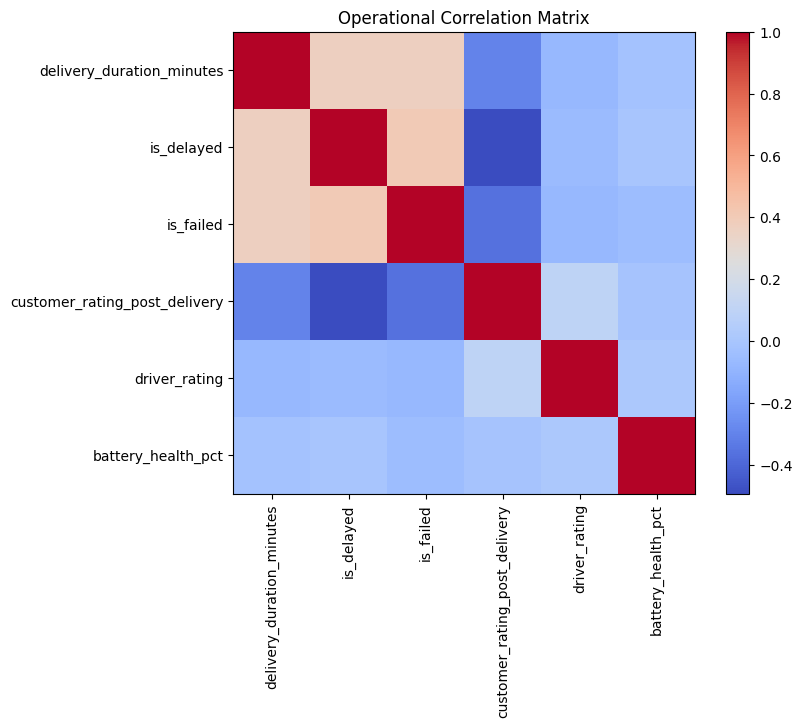

In [ ]:
# Visualise correlations using matplotlib

plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Operational Correlation Matrix")

plt.show()